<StringArray>
['000CT', '000EW', 'ME098']
Length: 3, dtype: str
Accuracy : 0.9908816321878384

Classification report :
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     16554
           1       0.88      0.98      0.92       993

    accuracy                           0.99     17547
   macro avg       0.94      0.98      0.96     17547
weighted avg       0.99      0.99      0.99     17547



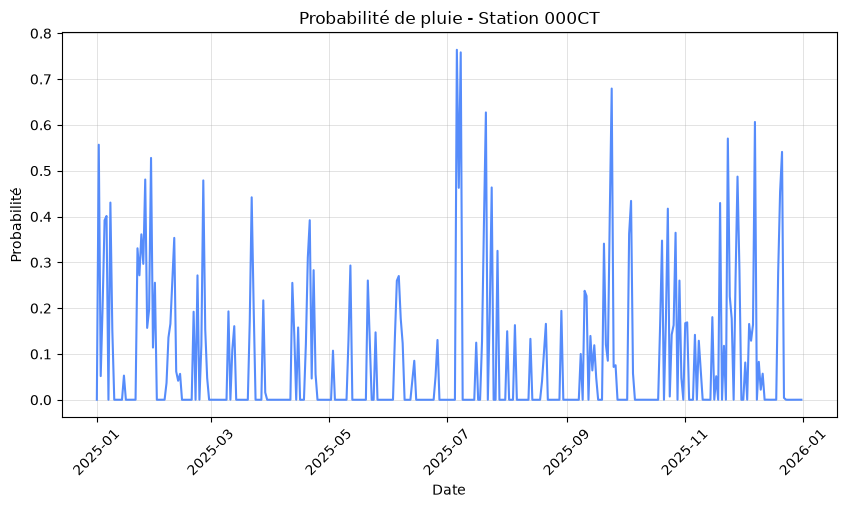

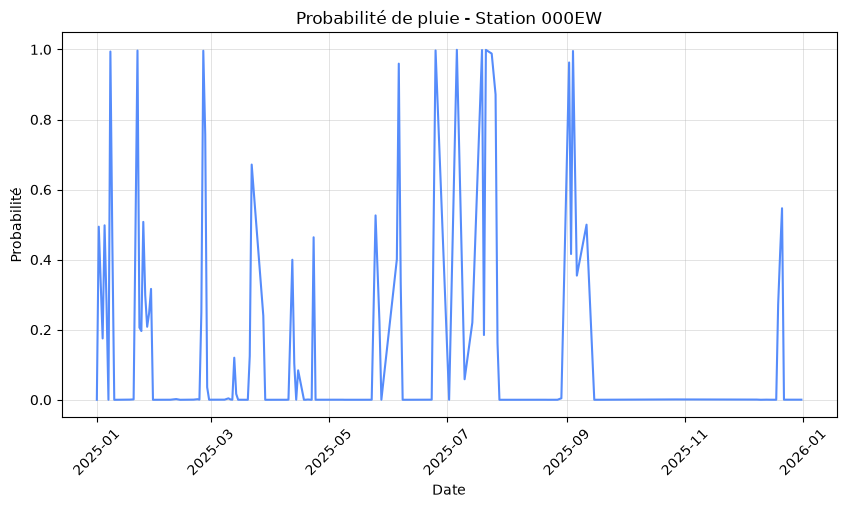

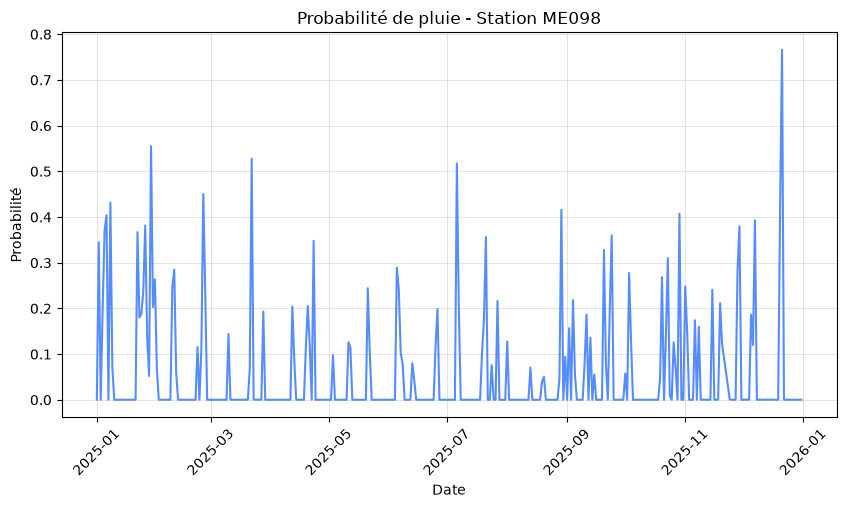

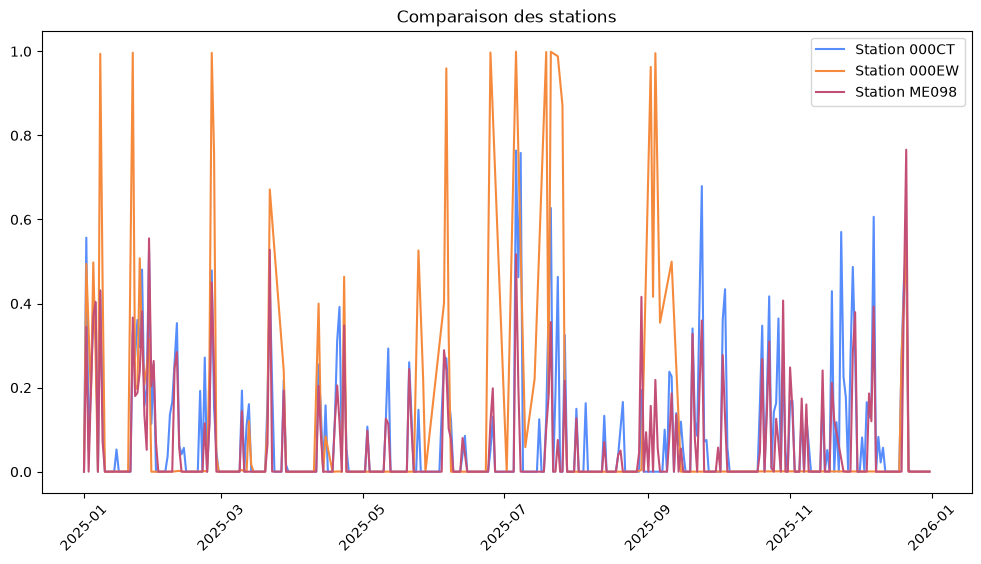

Données enregistrées dans SQLite
  station_id        date  proba_pluie  alerte     Interpretation Probabilité
0      000CT  2025-01-01     0.000344       0       Aucune pluie        0.0%
1      000CT  2025-01-02     0.556746       0        Incertitude       55.7%
2      000CT  2025-01-03     0.051809       0       Aucune pluie        5.2%
3      000CT  2025-01-04     0.206957       0  Très peu probable       20.7%
4      000CT  2025-01-05     0.391834       0      Faible risque       39.2%
5      000CT  2025-01-06     0.401247       0      Faible risque       40.1%
6      000CT  2025-01-07     0.000134       0       Aucune pluie        0.0%
7      000CT  2025-01-08     0.430470       0      Faible risque       43.0%
8      000CT  2025-01-09     0.152009       0  Très peu probable       15.2%
9      000CT  2025-01-10     0.000165       0       Aucune pluie        0.0%


In [3]:
import pandas as pd
import numpy as np
import xgboost as xgb

import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    classification_report
)

# Chargement du modèle préalablement entraîné :
model = xgb.XGBClassifier()
model.load_model("modele_prediction_pluie_V2.json")

# Chargement du dataset nettoyé 2025 :
df = pd.read_csv("donnees_meteo_2025_NETTOYEES.csv", sep=";")

# Conserver la date en format datetime :
df["dh_utc"] = pd.to_datetime(df["dh_utc"])

# Création de variables habituelles :
df["Mois"] = df["dh_utc"].dt.month
df["Heure"] = df["dh_utc"].dt.hour
df["variation_pression_3h"] = df["pression_hPa"] - df["pression_hPa"].shift(3)
df["variation_humidite_3h"] = df["humidite_%"] - df["humidite_%"].shift(3)
df["variation_vent_3h"] = df["vent_moyen_km/h"] - df["vent_moyen_km/h"].shift(3)
df["variation_pression_1h"] = df["pression_hPa"] - df["pression_hPa"].shift(1)
df["variation_humidite_1h"] = df["humidite_%"] - df["humidite_%"].shift(1)
df["variation_vent_1h"] = df["vent_moyen_km/h"] - df["vent_moyen_km/h"].shift(1)
# Historique pluie
df["pluie_1h_avant"] = df["pluie_1h_mm"].shift(1)
df["pluie_3h"] = df["pluie_1h_mm"].rolling(3).sum()
# Vent encodé
df["vent_dir_sin"] = np.sin(df["vent_direction_deg"] * np.pi / 180)
df["vent_dir_cos"] = np.cos(df["vent_direction_deg"] * np.pi / 180)

stations = df["station_id"].unique()
print(stations)

# Nettoyage
df = df.dropna()

# Définition des variables :
X = df.drop(columns=[
    "pleut_il",
    "station_id",
    "dh_utc",
    "vent_direction_deg",
    "pluie_1h_mm"
])

y = df["pleut_il"]

# Génération des probabilités de pluie :
threshold = 0.65
y_proba = model.predict_proba(X)[:, 1]
y_pred = (y_proba > threshold).astype(int)

# Ajout des prédictions dans le DataFrame :
df["proba_pluie"] = y_proba
df["prediction"] = y_pred

# Facultatif, pour suivre l'avancement :
print("Accuracy :", accuracy_score(y, y_pred))
print("\nClassification report :")
print(classification_report(y, y_pred))

# Facultatif, afficher les proba par station sur une année.
df["date"] = df["dh_utc"].dt.date
proba_station_jour = df.groupby(["station_id", "date"])["proba_pluie"].mean().reset_index()
station = proba_station_jour["station_id"].unique()
for station in stations:
    df_station = proba_station_jour[proba_station_jour["station_id"] == station]
    plt.figure(figsize=(10,5))
    plt.plot(df_station["date"], df_station["proba_pluie"])
    plt.title(f"Probabilité de pluie - Station {station}")
    plt.xlabel("Date")
    plt.ylabel("Probabilité")
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.show()
plt.figure(figsize=(12,6))

# Facultatif, comparer les stations entre elles :
for station in stations:
    df_station = proba_station_jour[
        proba_station_jour["station_id"] == station
    ]
    plt.plot(df_station["date"], df_station["proba_pluie"], label=f"Station {station}")
plt.legend()
plt.title("Comparaison des stations")
plt.xticks(rotation=45)
plt.show()

# Permet de traduire une probabilité en niveau de risque compréhensible :
def interpret_proba(p):
    if p < 0.10:
        return "Aucune pluie"
    elif p < 0.30:
        return "Très peu probable"
    elif p < 0.50:
        return "Faible risque"
    elif p < 0.65:
        return "Incertitude"
    elif p < 0.90:
        return "Probable"
    elif p < 1.00:
        return "Très probable"
    else:
        return "Pluie certaine"

# Fonction de conversion en pourcentage :
def interpret_proba2(p): return str(round(p * 100, 1)) + "%"

# Connexion à la base SQLite.
# SQLite est utilisé comme solution légère pour le MVP :
import sqlite3
# Connexion à la base SQLite :
conn = sqlite3.connect("GoutteDEAU.db")

# Création des colonnes "métier" :
proba_station_jour["alerte"] = (proba_station_jour["proba_pluie"] > 0.65).astype(int)
proba_station_jour["Interpretation"] = proba_station_jour["proba_pluie"].apply(interpret_proba)
proba_station_jour["Probabilité"] = proba_station_jour["proba_pluie"].apply(interpret_proba2)

# Enregistrement des données dans la table (par station et par date) :
proba_station_jour.to_sql(
    name="proba_pluie_station_jour",
    con=conn,
    if_exists="replace",  # remplace la table si elle existe
    index=False
)
conn.close()
print("Données enregistrées dans SQLite")

# Vérification rapide des données enregistrées :
conn = sqlite3.connect("GoutteDEAU.db")
df_check = pd.read_sql("SELECT * FROM proba_pluie_station_jour LIMIT 10",conn)

#Aperçu des données enregistrées :
print(df_check)

conn.close()

